## Exercise 1: Reading and Cleaning an HTML Table
Task: Find any other HTML data table online that could potentially be useful for your assignments project. Read it using read_html() function and apply appropriate cleaning.
- An HTML table containing population data for countries was fetched from Wikipedia. Cleaning was performed to normalize text, remove unwanted characters (e.g., commas), and convert columns to numeric types for further analysis.

In [37]:
import pandas as pd
from unicodedata import normalize

# Fetch and display an HTML table (Example: Wikipedia List of Countries by Population)
url = "https://en.wikipedia.org/wiki/List_of_countries_and_dependencies_by_population"
tables = pd.read_html(url, match="List of countries and territories by total population")
df_population = tables[0]  # Select the first matched table

# Clean percentage signs and convert to numeric values
df_population['% of world'] = df_population['% of world'].replace({'%': ''}, regex=True).astype('float')


#Rename column names for easier access:
df_population.rename(
    columns={
        'Source (official or from the United Nations)': 'Source',
        '% of world': 'Percentage world share'
    }, inplace=True
)

# Display initial info about the DataFrame
df_population.info()
df_population.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              240 non-null    object 
 1   Location                240 non-null    object 
 2   Population              240 non-null    int64  
 3   Percentage world share  240 non-null    float64
 4   Date                    240 non-null    object 
 5   Source                  240 non-null    object 
 6   Notes                   30 non-null     object 
dtypes: float64(1), int64(1), object(5)
memory usage: 13.2+ KB


,Unnamed: 0,Location,Population,Percentage world share,Date,Source,Notes
0,–,World,8119000000,100.0,1 Jul 2024,UN projection[1][3],NaN
1,1/2 [b],China,1409670000,17.3,31 Dec 2023,Official estimate[5],[c]
2,1/2 [b],India,1404910000,17.2,1 Jul 2024,Official projection[6],[d]
3,3,United States,335893238,4.1,1 Jan 2024,Official projection[7],[e]
4,4,Indonesia,282477584,3.5,31 Jun 2024,National annual projection[8],NaN


In [38]:
# Define a cleaning function for normalization
def clean_normalize_whitespace(x):
    if isinstance(x, str):
        return normalize('NFKC', x).strip()
    else:
        return x

# Apply cleaning function to the DataFrame
df_population = df_population.applymap(clean_normalize_whitespace)

# Display cleaned DataFrame
df_population.info()
df_population.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              240 non-null    object 
 1   Location                240 non-null    object 
 2   Population              240 non-null    int64  
 3   Percentage world share  240 non-null    float64
 4   Date                    240 non-null    object 
 5   Source                  240 non-null    object 
 6   Notes                   30 non-null     object 
dtypes: float64(1), int64(1), object(5)
memory usage: 13.2+ KB


/var/folders/qc/ylrp4vq57n590bhgm999r9fw0000gn/T/ipykernel_41027/856763810.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_population = df_population.applymap(clean_normalize_whitespace)


,Unnamed: 0,Location,Population,Percentage world share,Date,Source,Notes
0,–,World,8119000000,100.0,1 Jul 2024,UN projection[1][3],NaN
1,1/2 [b],China,1409670000,17.3,31 Dec 2023,Official estimate[5],[c]
2,1/2 [b],India,1404910000,17.2,1 Jul 2024,Official projection[6],[d]
3,3,United States,335893238,4.1,1 Jan 2024,Official projection[7],[e]
4,4,Indonesia,282477584,3.5,31 Jun 2024,National annual projection[8],NaN


## Exercise 2: Data Retrieval Using Social Media APIs
Task: Implement an example of data retrieval using one of the packages listed in the table (e.g., praw, tweepy, etc.).
- This task demonstrates how to retrieve real-time data from an external source using the `tweepy` library for Twitter.
- The program authenticates with Twitter's API using provided credentials and searches for recent tweets about "climate change."
- The retrieved tweets are processed and stored in a structured format using a pandas DataFrame, which includes the tweet's user, text, and creation date.
- This approach showcases how to integrate APIs to fetch structured data for further analysis.

In [43]:
import tweepy
import pandas as pd

# Set my credentials
bearer_token = "AAAAAAAAAAAAAAAAAAAAAL8mxQEAAAAANhWmG%2FRcTDK8Az1hp0FPZL9BQGI%3D86ycF4QfckBxLi3q78iCxR0cOUafZXpfHhZYja71XUEY7sINnO"

# Create a client for Twitter API v2
client = tweepy.Client(bearer_token=bearer_token)

# Search for recent tweets about "climate change"
query = "climate change lang:en"
tweets = client.search_recent_tweets(query=query, max_results=10)

# Extract relevant data
tweet_data = {
    "User": [tweet.author_id for tweet in tweets.data],
    "Text": [tweet.text for tweet in tweets.data],
    "Date": [tweet.created_at for tweet in tweets.data],
}

# Convert to a DataFrame
df_tweets = pd.DataFrame(tweet_data)

# Display the DataFrame
print(df_tweets.head())


   User                                               Text  Date
0  None  RT @wideawake_media: "For more than 80% of tim...  None
1  None  RT @ChrisMartzWX: Get a load of this. 🤣\n\nTwo...  None
2  None  RT @wideawake_media: "For more than 80% of tim...  None
3  None  RT @SandyofSuffolk: So, who's going to replace...  None
4  None  when ppl learn that climate change = intensifi...  None


## Exercise 3: Adding Legends to a Density Plot
Task: Add a legend to the plot with a caption for all lines on the plot.
- This task builds upon previous examples involving density plots, using skewed data generated with NumPy.
- The density plot shows the distribution of the skewed dataset.
- Vertical lines are added to highlight the mean and median of the data.
- A legend is added to the plot to clearly label the lines, allowing viewers to distinguish between the mean and median.
- The code demonstrates the importance of proper labeling and visual clarity in data visualization.

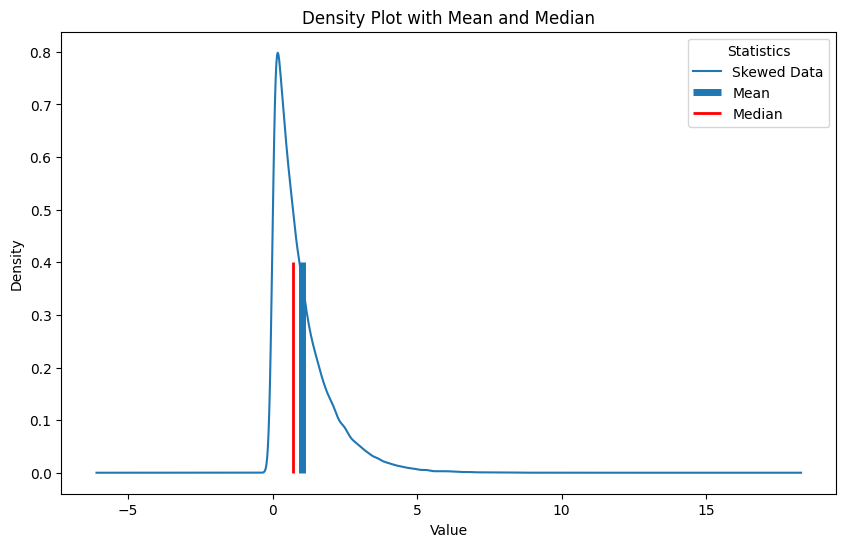

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generate skewed data
skewed_data = pd.DataFrame(np.random.exponential(size=100000), columns=["Skewed Data"])

# Plot density
plt.figure(figsize=(10, 6))
skewed_data.plot(kind="density", legend=False, ax=plt.gca())
plt.vlines(
    skewed_data["Skewed Data"].mean(), ymin=0, ymax=0.4, linewidth=5.0, label="Mean"
)
plt.vlines(
    skewed_data["Skewed Data"].median(),
    ymin=0,
    ymax=0.4,
    linewidth=2.0,
    color="red",
    label="Median",
)

# Add legend
plt.legend(title="Statistics")
plt.title("Density Plot with Mean and Median")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()


## Exercise 4: Boxplots for Numerical Columns
Task: Plot boxplots for all numerical columns in the dataset and provide your comments on what you observe.
- This task involves visualizing numerical columns in a dataset (`mpg` dataset) using boxplots.
- The `boxplot()` method in pandas was used to create boxplots for the numerical columns (`mpg`, `displacement`, `horsepower`, and `weight`).
- Observations about the spread, median, and outliers for each column were noted.
- This visualization helps to understand the distribution and variability of data across different features.

Numerical columns: Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year'],
      dtype='object')


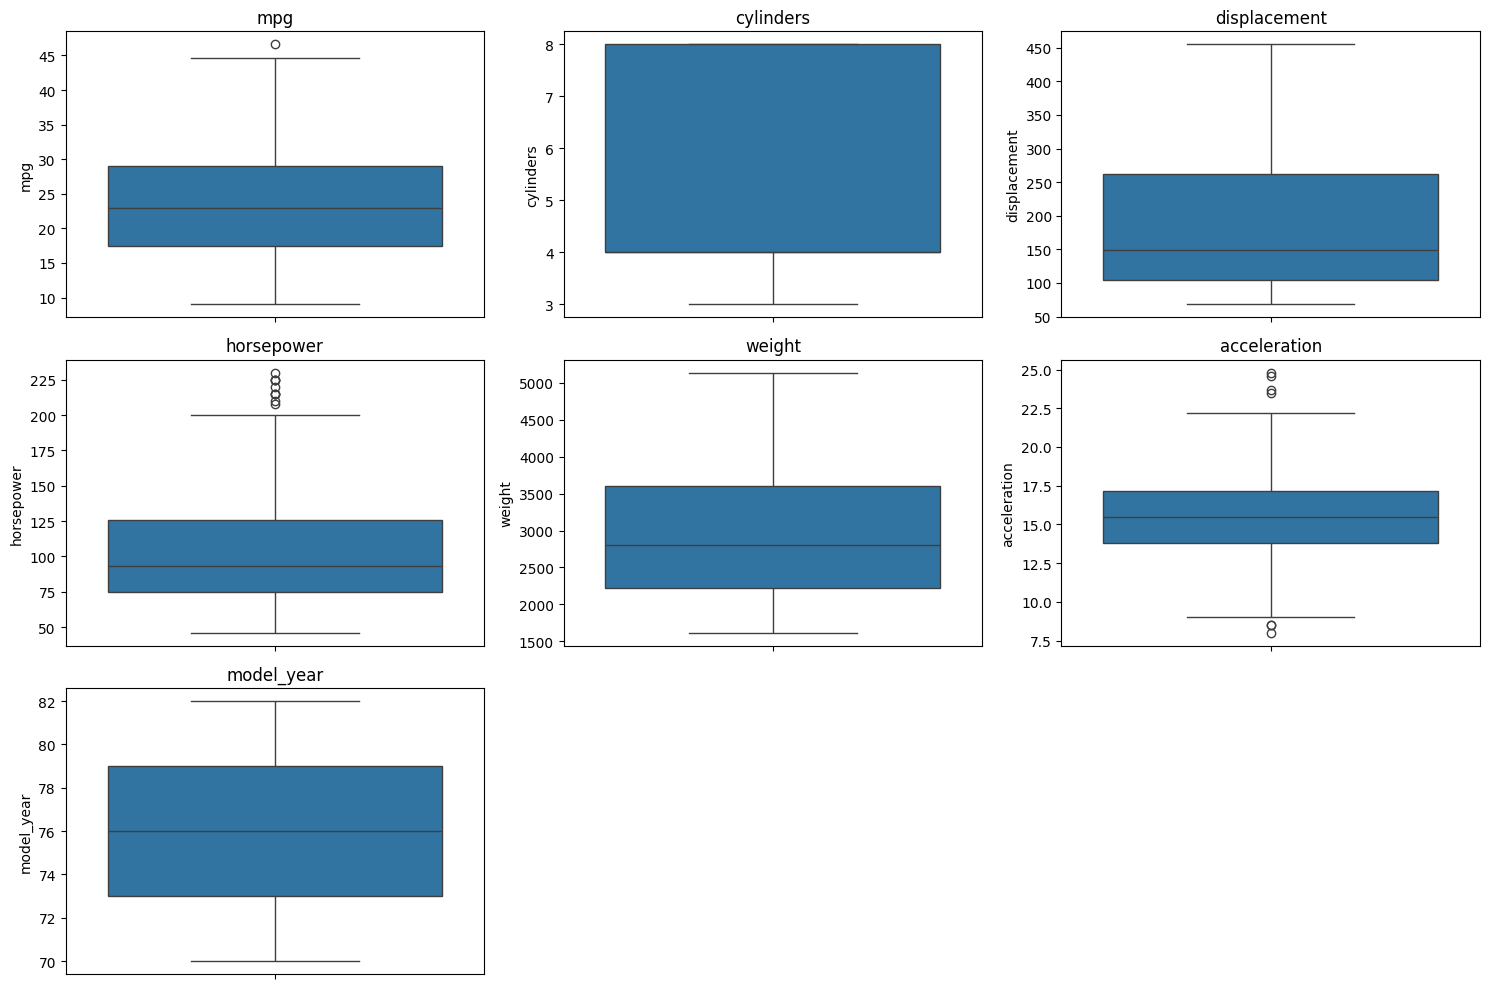

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the seaborn-data
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
mtcars = pd.read_csv(url)

# Display numerical columns
numerical_cols = mtcars.select_dtypes(include=[float, int]).columns
print("Numerical columns:", numerical_cols)

# Plot boxplots for all numerical columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=mtcars[col])
    plt.title(col)

plt.tight_layout()
plt.show()

## Conclusion
This lab provided hands-on experience in data acquisition, cleaning, and descriptive statistics using Python. Key takeaways include:
1. The ability to extract and clean structured data from web sources like HTML tables using `pandas.read_html`.
2. Proficiency in accessing unstructured data from social media APIs like Twitter.
3. Visualization of central tendency measures (mean and median) and their differences in symmetric and skewed distributions.
4. Understanding and visualizing variability, outliers, and spread in numerical datasets through boxplots and statistical measures like IQR and MAD.

These skills are essential for preparing datasets for advanced analysis and making data-driven decisions. The lab also emphasized the importance of cleaning and preprocessing data to avoid errors and inaccuracies during analysis.
